In [1]:
import sys
sys.path.append(r"C:\Users\saksh\OneDrive - University of Keele\Desktop\Ecommerce_project")

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score,
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

from src.data.loader import load_data
from src.features.engineering import add_engineered_features
from src.config.settings import load_config

config = load_config()


In [2]:
df = load_data()
df = add_engineered_features(df)
df = pd.get_dummies(df, columns=config["categorical_columns"])

X = df.drop(config["target_column"], axis=1)
y = df[config["target_column"]]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=config["test_size"], random_state=config["random_seed"]
)

2026-08-23 13:14:07,513 | INFO | src.data.loader | Data loaded successfully from C:/Users/saksh/OneDrive - University of Keele/Desktop/Ecommerce_project/dataset/ecommerce_sessions.csv.
2026-08-23 13:14:07,520 | INFO | src.data.loader | All expected columns are present in the dataset.
2026-08-23 13:14:07,539 | INFO | src.features.engineering | Engineered features added to the DataFrame.


In [3]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=5000, class_weight="balanced"),
    "DecisionTree": DecisionTreeClassifier(class_weight="balanced"),
    "RandomForest": RandomForestClassifier(class_weight="balanced", n_estimators=100),
    "XGBoost": XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.05, eval_metric="logloss", use_label_encoder=False),
    "CatBoost": CatBoostClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, verbose=0),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob),
    })

results_df = pd.DataFrame(results).sort_values("PR-AUC", ascending=False)
results_df


c:\Users\saksh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\saksh\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:14:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
3,XGBoost,0.934583,0.809659,0.760000,0.784044,0.969029,0.864373
4,CatBoost,0.936667,0.819484,0.762667,0.790055,0.969468,0.861221
2,RandomForest,0.917917,0.832090,0.594667,0.693624,0.962360,0.837381
0,LogisticRegression,0.915833,0.678351,0.877333,0.765116,0.959793,0.814471
1,DecisionTree,0.898750,0.685393,0.650667,0.667579,0.797679,0.500546


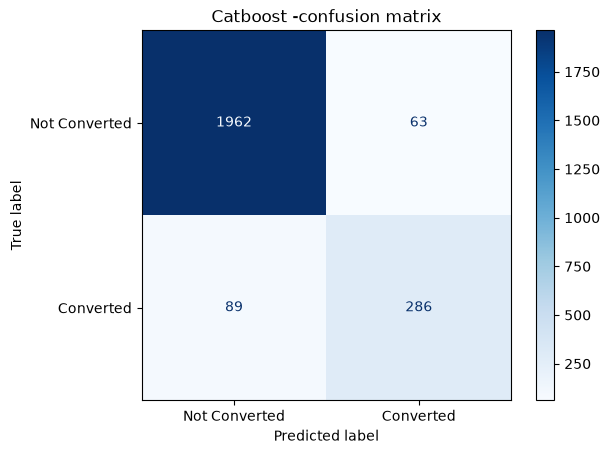

In [4]:
best_models= models["CatBoost"]
y_pred_best = best_models.predict(X_test)
cm  = confusion_matrix(y_test, y_pred_best)
dis = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Converted", "Converted"])
dis.plot(cmap="Blues")
plt.title("Catboost -confusion matrix")
plt.show()

In [7]:
from sklearn.metrics import precision_recall_curve
import plotly.express as px

y_prob_best = models['CatBoost'].predict_proba(X_test)[:, -1]
precision_val, recall_val, threshold = precision_recall_curve(y_test, y_prob_best)
fig = px.line(
    x = recall_val,  y = precision_val,
    labels = {"x": "recall", "y": "precision"},
    title =  "precision recall curve(Catboost)"
)

fig.show()



In [8]:
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-" * 48)

for t in [0.3, 0.35, 0.4, 0.45, 0.5, 0.6]:
    y_pred_t = (y_prob_best >= t).astype(int)
    p = precision_score(y_test, y_pred_t)
    r = recall_score(y_test, y_pred_t)
    f = f1_score(y_test, y_pred_t)
    print(f"{t:<12} {p:<12.4f} {r:<12.4f} {f:<12.4f}")

Threshold    Precision    Recall       F1          
------------------------------------------------
0.3          0.6958       0.8907       0.7813      
0.35         0.7168       0.8640       0.7836      
0.4          0.7452       0.8347       0.7874      
0.45         0.7831       0.7893       0.7862      
0.5          0.8195       0.7627       0.7901      
0.6          0.8401       0.6587       0.7384      
